<a href="https://colab.research.google.com/github/sudarshan-s-madiwal/Applied_ML_on_Student_Performance/blob/main/MLProject_30Apr2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ai_impact_student_performance_dataset.csv to ai_impact_student_performance_dataset.csv


In [ ]:
# ── Core libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn: preprocessing ───────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# ── Sklearn: models ───────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline

# ── Sklearn: metrics ─────────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Statsmodels: for VIF (multicollinearity) ─────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('✅ All libraries imported successfully!')



✅ All libraries imported successfully!


In [ ]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('ai_impact_student_performance_dataset.csv')

# Drop the 'Id' column — it's just an index, carries no information
#df.drop(columns=['Id'], inplace=True)

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

df.info()

Shape: (8000, 26)

First 5 rows:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       8000 non-null   int64  
 1   age                              8000 non-null   int64  
 2   gender                           8000 non-null   object 
 3   grade_level                      8000 non-null   object 
 4   study_hours_per_day              8000 non-null   float64
 5   uses_ai                          8000 non-null   int64  
 6   ai_usage_time_minutes            8000 non-null   int64  
 7   ai_tools_used                    6638 non-null   object 
 8   ai_usage_purpose                 6654 non-null   object 
 9   ai_dependency_score              8000 non-null   int64  
 10  ai_generated_content_percentage  8000 non-null   int64  
 11  ai_prompts_per_week              8000 non-null   

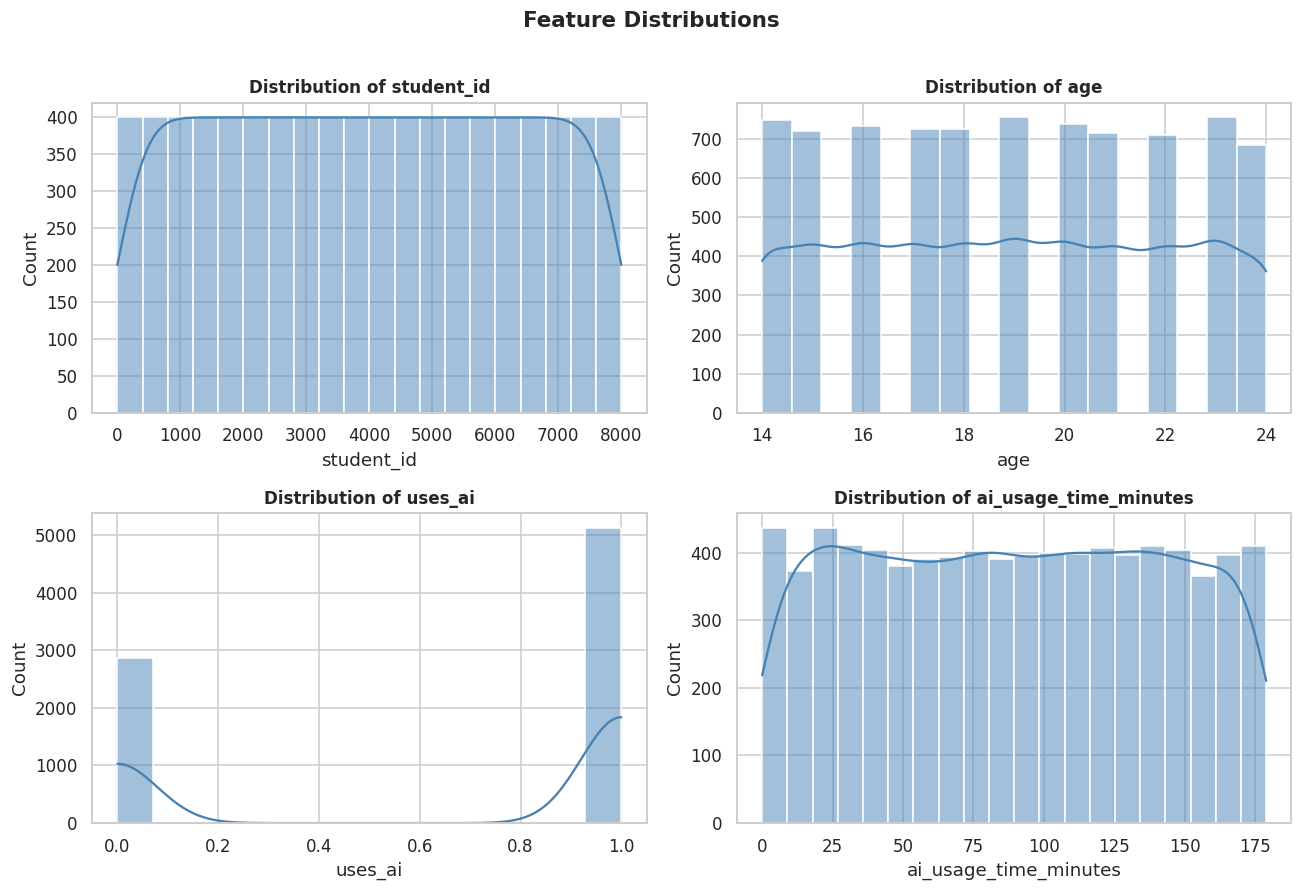

In [ ]:
# ── Visualise distributions ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
numeric_cols = ['student_id','age', 'uses_ai', 'ai_usage_time_minutes', 'ai_dependency_score']

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
print('Missing values before injection:')
print(df.isnull().sum())

Missing values before injection:
student_id                            0
age                                   0
gender                                0
grade_level                           0
study_hours_per_day                   0
uses_ai                               0
ai_usage_time_minutes                 0
ai_tools_used                      1362
ai_usage_purpose                   1346
ai_dependency_score                   0
ai_generated_content_percentage       0
ai_prompts_per_week                   0
ai_ethics_score                       0
last_exam_score                       0
assignment_scores_avg                 0
attendance_percentage                 0
concept_understanding_score           0
study_consistency_index               0
improvement_rate                      0
sleep_hours                           0
social_media_hours                    0
tutoring_hours                        0
class_participation_score             0
final_score                           0
passed 

In [ ]:
np.random.seed(42)
df_dirty = df.copy()

# Randomly set ~8% of SepalLengthCm and SepalWidthCm to NaN
# for col in ['SepalLengthCm', 'SepalWidthCm']:
#     missing_idx = np.random.choice(df_dirty.index, size=12, replace=False)
#     df_dirty.loc[missing_idx, col] = np.nan

print('Missing values after injection:')
print(df_dirty.isnull().sum())
print(f'\nTotal missing: {df_dirty.isnull().sum().sum()}')

Missing values after injection:
student_id                            0
age                                   0
gender                                0
grade_level                           0
study_hours_per_day                   0
uses_ai                               0
ai_usage_time_minutes                 0
ai_tools_used                      1362
ai_usage_purpose                   1346
ai_dependency_score                   0
ai_generated_content_percentage       0
ai_prompts_per_week                   0
ai_ethics_score                       0
last_exam_score                       0
assignment_scores_avg                 0
attendance_percentage                 0
concept_understanding_score           0
study_consistency_index               0
improvement_rate                      0
sleep_hours                           0
social_media_hours                    0
tutoring_hours                        0
class_participation_score             0
final_score                           0
passed  

In [ ]:
df_model = df.copy()

# ── Define Features (X) and Target (y) ───────────────────────────────────────
# TASK: Predict PetalLengthCm from the other numeric features
FEATURES = [
    'age',
    'gender',
    'grade_level',
    'study_hours_per_day',
    'uses_ai',
    'ai_usage_time_minutes',
    'ai_dependency_score',
    'ai_generated_content_percentage',
    'ai_prompts_per_week',
    'ai_ethics_score',
    'last_exam_score',
    'assignment_scores_avg',
    'attendance_percentage',
    'concept_understanding_score',
    'study_consistency_index',
    'improvement_rate',
    'sleep_hours',
    'social_media_hours',
    'tutoring_hours',
    'class_participation_score']

TARGET = ['final_score', 'passed','performance_category']

# Extract X and y
X = df_model[FEATURES]
y = df_model[TARGET]

print(f'Feature matrix X: {X.shape}  → {X.shape[0]} samples, {X.shape[1]} features')
print("")
print(f'Target vector  y: {y.shape}  → {y.shape[0]} samples')

Feature matrix X: (8000, 20)  → 8000 samples, 20 features

Target vector  y: (8000, 3)  → 8000 samples


Training set   : 7600 samples (95%)
Test set       : 400 samples  (5%)


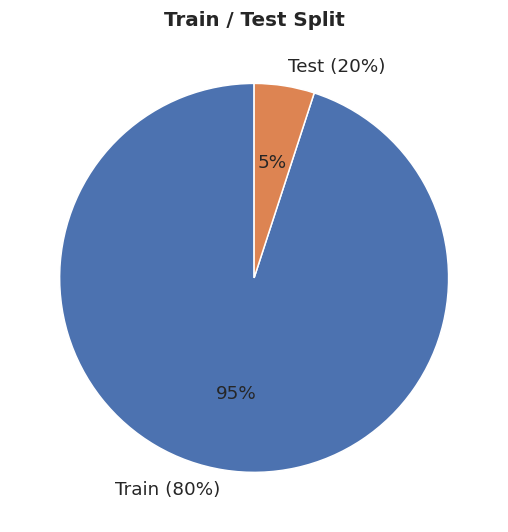

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.05,
    random_state=42
)

print(f'Training set   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set       : {X_test.shape[0]} samples  ({X_test.shape[0]/len(X)*100:.0f}%)')


labels = ['Train (80%)', 'Test (20%)']
sizes  = [X_train.shape[0], X_test.shape[0]]
colors = ['#4C72B0', '#DD8452']

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.0f%%',
       startangle=90, textprops={'fontsize': 12})
ax.set_title('Train / Test Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
le = LabelEncoder()
# encoded = le.fit_transform(df_model[''])

# print('T Encoding (LabelEncoder):')
# for name, code in zip(le.classes_, range(len(le.classes_))):
#    print(f'  {name:20s} → {code}')

KeyError: ''

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # learn μ & σ from train only
X_test_scaled  = scaler.transform(X_test)         # apply SAME μ & σ to test



# Convert back to DataFrame for readability
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURES)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=FEATURES)

print('Before scaling (X_train stats):')
print(X_train.describe().round(2))
print('\nAfter StandardScaling (X_train_scaled stats):')
print(X_train_scaled_df.describe().round(2))

ValueError: could not convert string to float: 'Male'